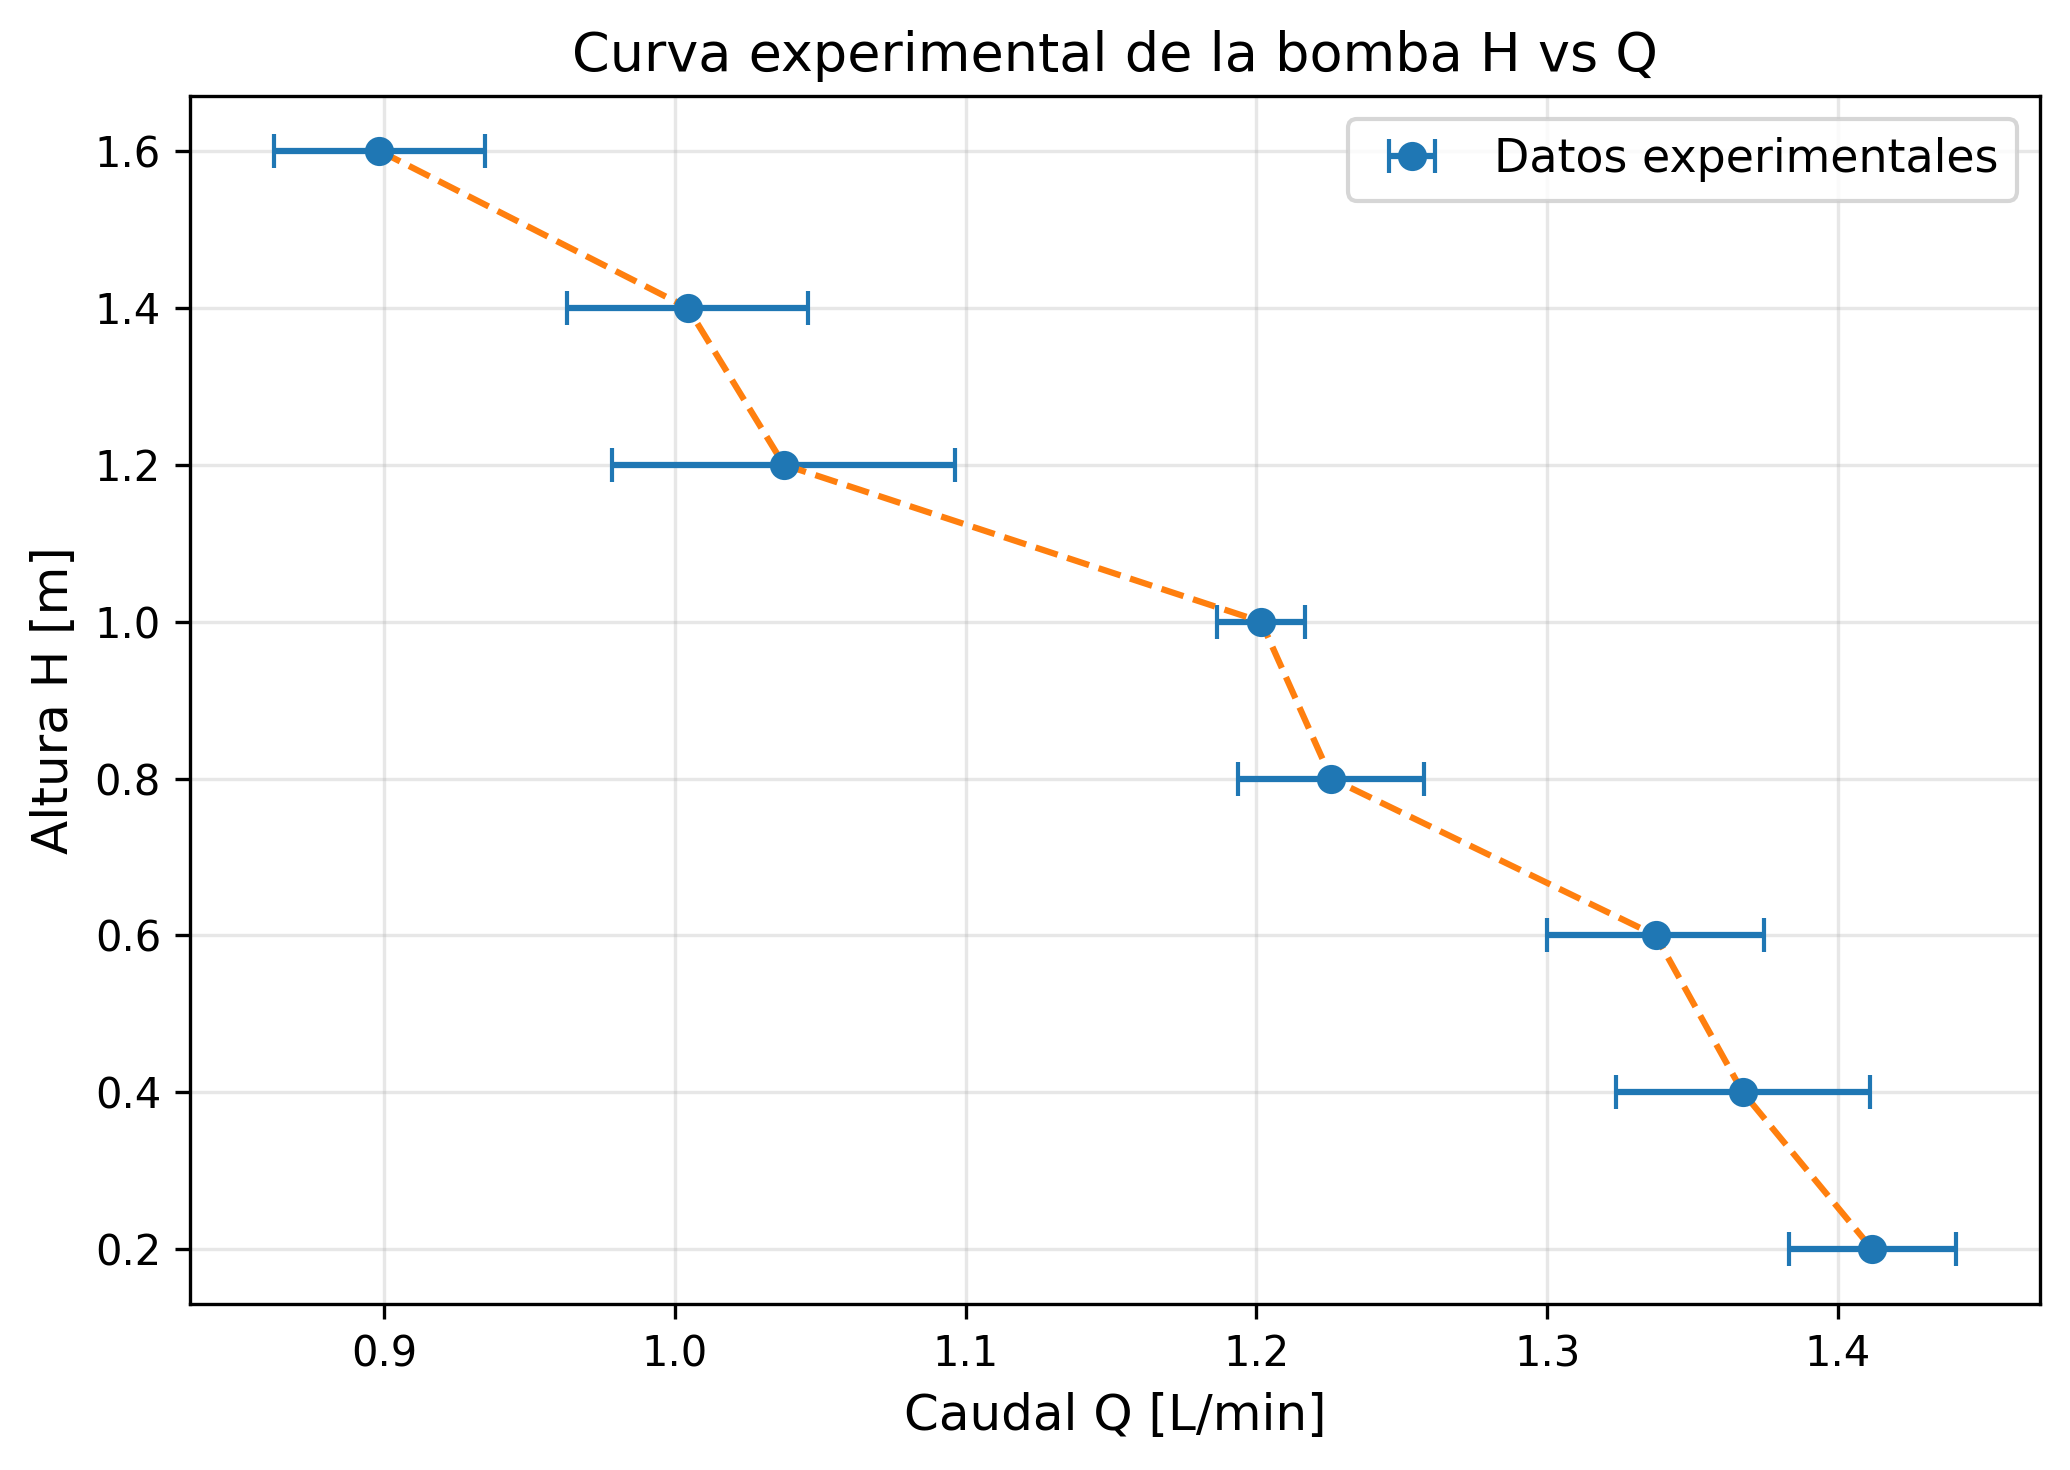

h1: H = 1.60 m, t_prom = 13.36 s, Q = 0.898 L/min
h2: H = 1.40 m, t_prom = 11.95 s, Q = 1.004 L/min
h3: H = 1.20 m, t_prom = 11.57 s, Q = 1.037 L/min
h4: H = 1.00 m, t_prom = 9.99 s, Q = 1.202 L/min
h5: H = 0.80 m, t_prom = 9.79 s, Q = 1.226 L/min
h6: H = 0.60 m, t_prom = 8.97 s, Q = 1.337 L/min
h7: H = 0.40 m, t_prom = 8.78 s, Q = 1.367 L/min
h8: H = 0.20 m, t_prom = 8.50 s, Q = 1.412 L/min


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Datos experimentales
# =========================

# Alturas: h8 = 20 cm, h7 = 40 cm, ..., h1 = 160 cm
H_cm = np.array([160, 140, 120, 100, 80, 60, 40, 20])
H_m = H_cm / 100

# Tiempos medidos en segundos para llenar 200 mL
tiempos = np.array([
    [12.79, 13.42, 13.86],  # h1
    [11.38, 12.27, 12.19],  # h2
    [10.81, 11.89, 12.00],  # h3
    [9.99,  9.86,  10.11],  # h4
    [9.53,  9.80,  10.04],  # h5
    [8.80,  8.86,  9.26],   # h6
    [8.60,  8.63,  9.10],   # h7
    [8.60,  8.30,  8.60]    # h8
])

# Volumen llenado
V_ml = 200
V_L = V_ml / 1000  # litros

# =========================
# Cálculo de caudal
# =========================

t_prom = np.mean(tiempos, axis=1)
t_std = np.std(tiempos, axis=1, ddof=1)

# Caudal en L/s
Q_Ls = V_L / t_prom

# Caudal en L/min
Q_Lmin = Q_Ls * 60

# Incertidumbre aproximada del caudal
Q_std_Lmin = Q_Lmin * (t_std / t_prom)

# =========================
# Gráfico H vs Q
# =========================

plt.figure(figsize=(7, 5), dpi=300)

plt.errorbar(
    Q_Lmin,
    H_m,
    xerr=Q_std_Lmin,
    fmt='o',
    capsize=4,
    label='Datos experimentales'
)

plt.plot(Q_Lmin, H_m, linestyle='--')

plt.xlabel('Caudal Q [L/min]', fontsize=12)
plt.ylabel('Altura H [m]', fontsize=12)
plt.title('Curva experimental de la bomba H vs Q', fontsize=13)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# =========================
# Mostrar tabla de resultados
# =========================

for i in range(len(H_m)):
    print(
        f"h{i+1}: H = {H_m[i]:.2f} m, "
        f"t_prom = {t_prom[i]:.2f} s, "
        f"Q = {Q_Lmin[i]:.3f} L/min"
    )